by: Victor Camero

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier 
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import seaborn as sns


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/dalark/.local/lib/python3.13/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/dalark/.local/lib/python3.13/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/dalark/.local/lib/python3.13/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/home/dalark/.local/

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [2]:
dataset_el_pino = pd.read_csv("../data/dataModelCSV/withingLastNumberGRD.csv", sep=";")
dataset_el_pino.head()

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8,B37.6,I39.8,N10,B96.1,L89.9,L08.9,B96.2,A41.5,J86.9,...,99.84,88.72,90.42,90.52,91.39,91.33,87.03,40,1,18410
1,U07.1,J12.8,R06.0,R05,R50.9,Z29.0,Z01.7,J96.00,J94.2,J92.9,...,91.62,90.43,91.39,90.52,91.32,96.59,90.99,53,1,4101
2,K56.5,R57.2,R57.1,J80,Y95,J15.0,U82.2,B95.6,B96.8,B37.1,...,99.84,91.73,90.53,99.26,89.39,89.66,89.65,65,1,4101
3,K76.8,K66.1,N18.5,D64.9,E87.5,E87.2,J81,N17.8,J44.9,R41.0,...,57.94,0.13,0.17,99.04,99.18,99.21,99.23,61,1,4102
4,T81.0,Y83.2,S31.1,S36.80,W31.62,J96.09,J15.0,U82.2,U07.1,N39.0,...,90.52,91.39,91.32,93.90,99.15,96.59,45.13,30,1,4102


In [3]:
rows, columns = dataset_el_pino.shape
rows

14278

In [4]:
dataset_el_pino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14278 entries, 0 to 14277
Data columns (total 68 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Diag 01 Principal (cod+des)     14278 non-null  object 
 1   Diag 02 Secundario (cod+des)    14278 non-null  object 
 2   Diag 03 Secundario (cod+des)    14278 non-null  object 
 3   Diag 04 Secundario (cod+des)    14278 non-null  object 
 4   Diag 05 Secundario (cod+des)    14278 non-null  object 
 5   Diag 06 Secundario (cod+des)    14278 non-null  object 
 6   Diag 07 Secundario (cod+des)    14278 non-null  object 
 7   Diag 08 Secundario (cod+des)    14278 non-null  object 
 8   Diag 09 Secundario (cod+des)    14278 non-null  object 
 9   Diag 10 Secundario (cod+des)    14278 non-null  object 
 10  Diag 11 Secundario (cod+des)    14278 non-null  object 
 11  Diag 12 Secundario (cod+des)    14278 non-null  object 
 12  Diag 13 Secundario (cod+des)    

In [5]:
dataset_el_pino.isnull().sum()

Diag 01 Principal (cod+des)       0
Diag 02 Secundario (cod+des)      0
Diag 03 Secundario (cod+des)      0
Diag 04 Secundario (cod+des)      0
Diag 05 Secundario (cod+des)      0
                                 ..
Proced 29 Secundario (cod+des)    0
Proced 30 Secundario (cod+des)    0
Edad en años                      0
Sexo (Desc)                       0
GRD                               0
Length: 68, dtype: int64

# Label encoding 

In [6]:
name_columns_for_label = dataset_el_pino.columns.tolist()

# I will delete age and sex in the columns of the dataset 
name_columns_for_label.remove('Edad en años')
name_columns_for_label.remove('Sexo (Desc)')

In [7]:
columns_name = dataset_el_pino.columns.tolist()
columns_name

['Diag 01 Principal (cod+des)',
 'Diag 02 Secundario (cod+des)',
 'Diag 03 Secundario (cod+des)',
 'Diag 04 Secundario (cod+des)',
 'Diag 05 Secundario (cod+des)',
 'Diag 06 Secundario (cod+des)',
 'Diag 07 Secundario (cod+des)',
 'Diag 08 Secundario (cod+des)',
 'Diag 09 Secundario (cod+des)',
 'Diag 10 Secundario (cod+des)',
 'Diag 11 Secundario (cod+des)',
 'Diag 12 Secundario (cod+des)',
 'Diag 13 Secundario (cod+des)',
 'Diag 14 Secundario (cod+des)',
 'Diag 15 Secundario (cod+des)',
 'Diag 16 Secundario (cod+des)',
 'Diag 17 Secundario (cod+des)',
 'Diag 18 Secundario (cod+des)',
 'Diag 19 Secundario (cod+des)',
 'Diag 20 Secundario (cod+des)',
 'Diag 21 Secundario (cod+des)',
 'Diag 22 Secundario (cod+des)',
 'Diag 23 Secundario (cod+des)',
 'Diag 24 Secundario (cod+des)',
 'Diag 25 Secundario (cod+des)',
 'Diag 26 Secundario (cod+des)',
 'Diag 27 Secundario (cod+des)',
 'Diag 28 Secundario (cod+des)',
 'Diag 29 Secundario (cod+des)',
 'Diag 30 Secundario (cod+des)',
 'Diag 31 S

In [8]:
name_columns_for_label[2]

'Diag 03 Secundario (cod+des)'

In [9]:
label_encoding = LabelEncoder()
for col_name in name_columns_for_label:
    dataset_el_pino[col_name] = label_encoding.fit_transform(dataset_el_pino[col_name])

In [10]:
dataset_el_pino.head()

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,24,41,373,638,38,462,391,26,6,242,...,112,19,40,40,41,39,13,40,1,135
1,1364,508,1016,889,796,833,693,297,260,244,...,57,42,53,40,39,73,39,53,1,14
2,575,1177,1051,452,975,330,649,23,31,9,...,112,54,44,99,22,26,26,65,1,14
3,622,670,711,120,169,149,321,411,251,411,...,18,1,3,90,90,82,86,61,1,15
4,1342,1571,1102,964,923,362,297,574,491,349,...,46,53,51,72,88,73,9,30,1,15


# Write new CSV

In [11]:
# dataset_el_pino.to_csv("../data/dataModelCSV/label_encoding.csv", sep=';', index=False)

In [76]:
delete_rows = [["GRD"], # Modelo 1 y 2
              ["GRD", "Edad en años", "Sexo (Desc)"], # Modelo 3 y 4
               ['Diag 03 Secundario (cod+des)',
 'Diag 04 Secundario (cod+des)',
 'Diag 05 Secundario (cod+des)',
 'Diag 06 Secundario (cod+des)',
 'Diag 07 Secundario (cod+des)',
 'Diag 08 Secundario (cod+des)',
 'Diag 09 Secundario (cod+des)',
 'Diag 10 Secundario (cod+des)',
 'Diag 11 Secundario (cod+des)',
 'Diag 12 Secundario (cod+des)',
 'Diag 13 Secundario (cod+des)',
 'Diag 14 Secundario (cod+des)',
 'Diag 15 Secundario (cod+des)',
 'Diag 16 Secundario (cod+des)',
 'Diag 17 Secundario (cod+des)',
 'Diag 18 Secundario (cod+des)',
 'Diag 19 Secundario (cod+des)',
 'Diag 20 Secundario (cod+des)',
 'Diag 21 Secundario (cod+des)',
 'Diag 22 Secundario (cod+des)',
 'Diag 23 Secundario (cod+des)',
 'Diag 24 Secundario (cod+des)',
 'Diag 25 Secundario (cod+des)',
 'Diag 26 Secundario (cod+des)',
 'Diag 27 Secundario (cod+des)',
 'Diag 28 Secundario (cod+des)',
 'Diag 29 Secundario (cod+des)',
 'Diag 30 Secundario (cod+des)',
 'Diag 31 Secundario (cod+des)',
 'Diag 32 Secundario (cod+des)',
 'Diag 33 Secundario (cod+des)',
 'Diag 34 Secundario (cod+des)',
 'Diag 35 Secundario (cod+des)','Proced 06 Secundario (cod+des)',
 'Proced 07 Secundario (cod+des)',
 'Proced 08 Secundario (cod+des)',
 'Proced 09 Secundario (cod+des)',
 'Proced 10 Secundario (cod+des)',
 'Proced 11 Secundario (cod+des)',
 'Proced 12 Secundario (cod+des)',
 'Proced 13 Secundario (cod+des)',
 'Proced 14 Secundario (cod+des)',
 'Proced 15 Secundario (cod+des)',
 'Proced 16 Secundario (cod+des)',
 'Proced 17 Secundario (cod+des)',
 'Proced 18 Secundario (cod+des)',
 'Proced 19 Secundario (cod+des)',
 'Proced 20 Secundario (cod+des)',
 'Proced 21 Secundario (cod+des)',
 'Proced 22 Secundario (cod+des)',
 'Proced 23 Secundario (cod+des)',
 'Proced 24 Secundario (cod+des)',
 'Proced 25 Secundario (cod+des)',
 'Proced 26 Secundario (cod+des)',
 'Proced 27 Secundario (cod+des)',
 'Proced 28 Secundario (cod+des)',
 'Proced 29 Secundario (cod+des)',
 'Proced 30 Secundario (cod+des)'], # Model 5 y 6
               ['Diag 03 Secundario (cod+des)',
 'Diag 04 Secundario (cod+des)',
 'Diag 05 Secundario (cod+des)',
 'Diag 06 Secundario (cod+des)',
 'Diag 07 Secundario (cod+des)',
 'Diag 08 Secundario (cod+des)',
 'Diag 09 Secundario (cod+des)',
 'Diag 10 Secundario (cod+des)',
 'Diag 11 Secundario (cod+des)',
 'Diag 12 Secundario (cod+des)',
 'Diag 13 Secundario (cod+des)',
 'Diag 14 Secundario (cod+des)',
 'Diag 15 Secundario (cod+des)',
 'Diag 16 Secundario (cod+des)',
 'Diag 17 Secundario (cod+des)',
 'Diag 18 Secundario (cod+des)',
 'Diag 19 Secundario (cod+des)',
 'Diag 20 Secundario (cod+des)',
 'Diag 21 Secundario (cod+des)',
 'Diag 22 Secundario (cod+des)',
 'Diag 23 Secundario (cod+des)',
 'Diag 24 Secundario (cod+des)',
 'Diag 25 Secundario (cod+des)',
 'Diag 26 Secundario (cod+des)',
 'Diag 27 Secundario (cod+des)',
 'Diag 28 Secundario (cod+des)',
 'Diag 29 Secundario (cod+des)',
 'Diag 30 Secundario (cod+des)',
 'Diag 31 Secundario (cod+des)',
 'Diag 32 Secundario (cod+des)',
 'Diag 33 Secundario (cod+des)',
 'Diag 34 Secundario (cod+des)',
 'Diag 35 Secundario (cod+des)','Proced 06 Secundario (cod+des)',
 'Proced 07 Secundario (cod+des)',
 'Proced 08 Secundario (cod+des)',
 'Proced 09 Secundario (cod+des)',
 'Proced 10 Secundario (cod+des)',
 'Proced 11 Secundario (cod+des)',
 'Proced 12 Secundario (cod+des)',
 'Proced 13 Secundario (cod+des)',
 'Proced 14 Secundario (cod+des)',
 'Proced 15 Secundario (cod+des)',
 'Proced 16 Secundario (cod+des)',
 'Proced 17 Secundario (cod+des)',
 'Proced 18 Secundario (cod+des)',
 'Proced 19 Secundario (cod+des)',
 'Proced 20 Secundario (cod+des)',
 'Proced 21 Secundario (cod+des)',
 'Proced 22 Secundario (cod+des)',
 'Proced 23 Secundario (cod+des)',
 'Proced 24 Secundario (cod+des)',
 'Proced 25 Secundario (cod+des)',
 'Proced 26 Secundario (cod+des)',
 'Proced 27 Secundario (cod+des)',
 'Proced 28 Secundario (cod+des)',
 'Proced 29 Secundario (cod+des)',
 'Proced 30 Secundario (cod+des)', 'Sexo (Desc)']
              ]

# Modelos con oneShot

## Modelo 1

In [13]:
Explicativas1 = dataset_el_pino.drop(columns=delete_rows[0])
Objetivo1 = dataset_el_pino.GRD

In [14]:
Explicativas1

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 23 Secundario (cod+des),Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc)
0,24,41,373,638,38,462,391,26,6,242,...,44,112,19,40,40,41,39,13,40,1
1,1364,508,1016,889,796,833,693,297,260,244,...,16,57,42,53,40,39,73,39,53,1
2,575,1177,1051,452,975,330,649,23,31,9,...,44,112,54,44,99,22,26,26,65,1
3,622,670,711,120,169,149,321,411,251,411,...,92,18,1,3,90,90,82,86,61,1
4,1342,1571,1102,964,923,362,297,574,491,349,...,116,46,53,51,72,88,73,9,30,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14273,667,378,158,168,202,919,0,0,0,0,...,0,0,0,0,0,0,0,0,48,1
14274,177,552,214,219,1093,0,0,0,0,0,...,0,0,0,0,0,0,0,0,26,0
14275,1170,1416,1047,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,10,1
14276,656,378,158,370,435,469,201,743,0,0,...,0,0,0,0,0,0,0,0,58,1


In [15]:
modelo1 = DecisionTreeClassifier(max_depth=5)
modelo1.fit(Explicativas1, Objetivo1)

DecisionTreeClassifier(max_depth=5)

In [16]:
DecisionTreeClassifier()

DecisionTreeClassifier()

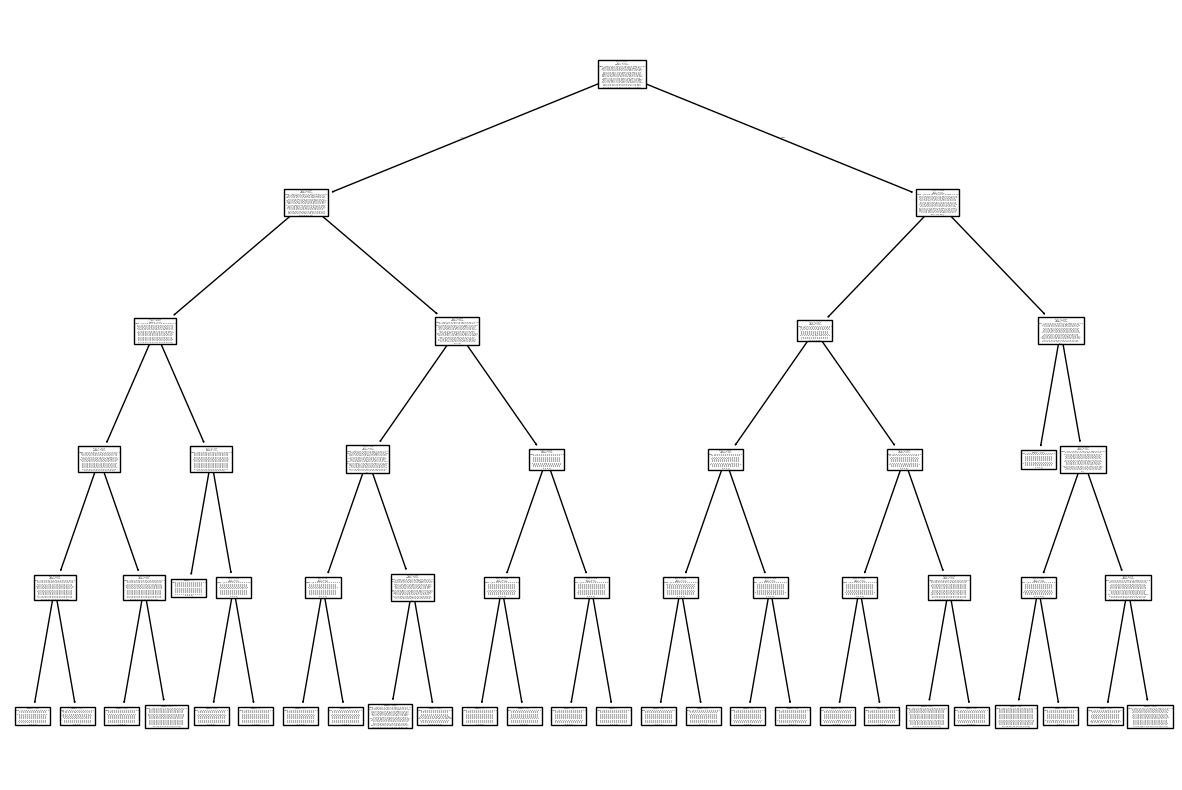

In [17]:
plt.figure(figsize=(15,10))
plot_tree(modelo1)
plt.show()

In [18]:
test_ejemplo1 = Explicativas1.sample()
test_ejemplo1

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 23 Secundario (cod+des),Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc)
5927,946,999,852,1157,1000,852,719,629,0,0,...,0,0,0,0,0,0,0,0,26,0


In [19]:
modelo1.predict_proba(test_ejemplo1)

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

In [20]:
predecir_grd1 = modelo1.predict(Explicativas1)
predecir_grd1

array([22, 26, 22, ..., 21, 22, 21], shape=(14278,))

In [21]:
dataset_el_pino['GRD'] == predecir_grd1

0        False
1        False
2        False
3        False
4        False
         ...  
14273    False
14274    False
14275    False
14276    False
14277    False
Name: GRD, Length: 14278, dtype: bool

In [22]:
porcentaje1 = np.round(((dataset_el_pino['GRD'] == predecir_grd1).sum())/rows * 100, decimals=2)
print(f"Porcentaje del modelo: {porcentaje1}%")

Porcentaje del modelo: 44.06%


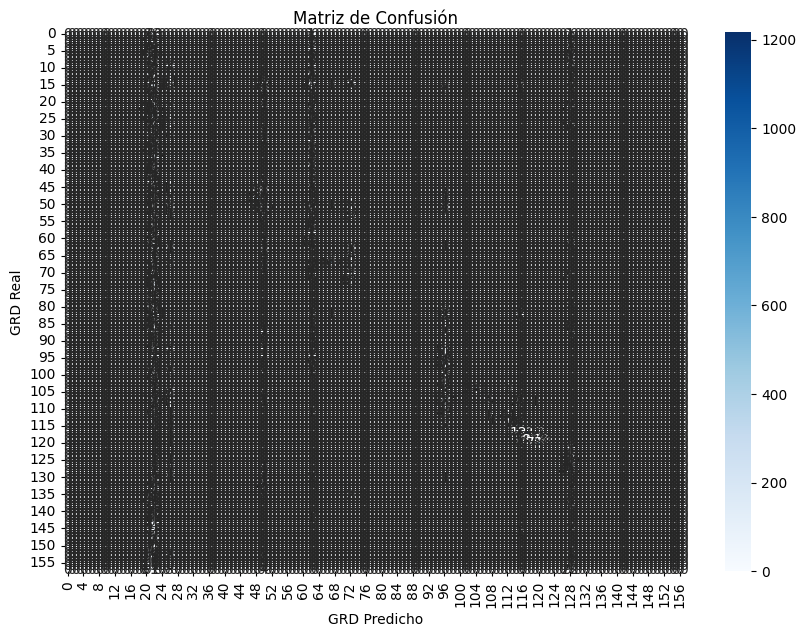

In [23]:
# Calcular la matriz de confusión
matriz_confusion1 = confusion_matrix(dataset_el_pino['GRD'], predecir_grd1)

# Mostrarla como heatmap
plt.figure(figsize=(10,7))
sns.heatmap(matriz_confusion1, annot=True, fmt="d", cmap="Blues")
plt.xlabel('GRD Predicho')
plt.ylabel('GRD Real')
plt.title('Matriz de Confusión')
plt.show()


In [24]:
# Calcular accuracy
accuracy = accuracy_score(dataset_el_pino['GRD'], predecir_grd1)
print(f"Accuracy: {accuracy:.2f}")

# Calcular precision
precision = precision_score(dataset_el_pino['GRD'], predecir_grd1, average='macro')
print(f"Precision (macro): {precision:.2f}")

# Calcular recall
recall = recall_score(dataset_el_pino['GRD'], predecir_grd1, average='macro')
print(f"Recall (macro): {recall:.2f}")

Accuracy: 0.44
Precision (macro): 0.08
Recall (macro): 0.09


/home/dalark/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Modelo 2

In [25]:
Explicativas2 = dataset_el_pino.drop(columns=delete_rows[0])
Objetivo2 = dataset_el_pino.GRD

In [26]:
modelo2 = DecisionTreeClassifier(max_depth=20)
modelo2.fit(Explicativas2, Objetivo2)

DecisionTreeClassifier(max_depth=20)

In [27]:
DecisionTreeClassifier()

DecisionTreeClassifier()

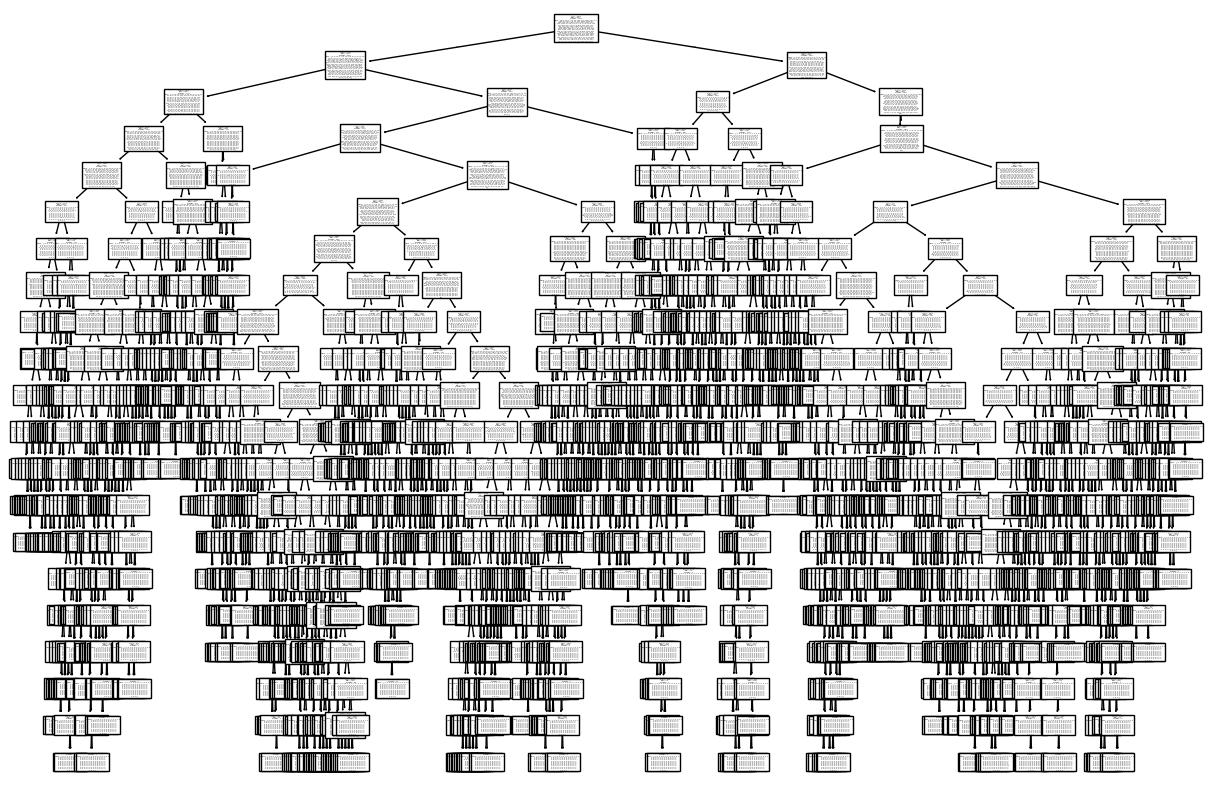

In [28]:
plt.figure(figsize=(15,10))
plot_tree(modelo2)
plt.show()

In [29]:
test_ejemplo2 = Explicativas2.sample()
test_ejemplo2

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 23 Secundario (cod+des),Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc)
9850,716,378,178,1272,1100,943,0,0,0,0,...,0,0,0,0,0,0,0,0,39,0


In [30]:
modelo2.predict_proba(test_ejemplo2)

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [31]:
predecir_grd2 = modelo2.predict(Explicativas2)
predecir_grd2

array([135,  14,  52, ...,   6,  62,  16], shape=(14278,))

In [32]:
dataset_el_pino['GRD'] == predecir_grd2

0         True
1         True
2        False
3         True
4         True
         ...  
14273     True
14274     True
14275     True
14276     True
14277     True
Name: GRD, Length: 14278, dtype: bool

In [33]:
porcentaje2 = np.round(((dataset_el_pino['GRD'] == predecir_grd2).sum())/rows * 100, decimals=2)
print(f"Porcentaje del modelo: {porcentaje2}%")

Porcentaje del modelo: 99.09%


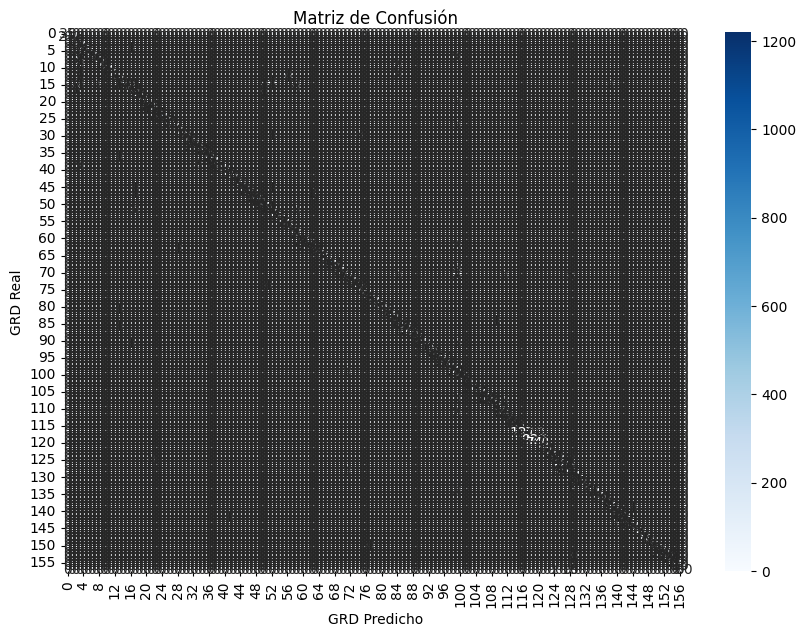

In [34]:
# Calcular la matriz de confusión
matriz_confusion2 = confusion_matrix(dataset_el_pino['GRD'], predecir_grd2)

# Mostrarla como heatmap
plt.figure(figsize=(10,7))
sns.heatmap(matriz_confusion2, annot=True, fmt="d", cmap="Blues")
plt.xlabel('GRD Predicho')
plt.ylabel('GRD Real')
plt.title('Matriz de Confusión')
plt.show()


In [35]:
def medir_modelos(predecir):
    # Calcular accuracy
    accuracy = accuracy_score(dataset_el_pino['GRD'], predecir) * 100
    print(f"Accuracy: {accuracy:.2f}%")
    
    # Calcular precision
    precision = precision_score(dataset_el_pino['GRD'], predecir, average='macro') * 100
    print(f"Precision (macro): {precision:.2f}%")
    
    # Calcular recall
    recall = recall_score(dataset_el_pino['GRD'], predecir, average='macro') * 100
    print(f"Recall (macro): {recall:.2f}%")


In [36]:
medir_modelos(predecir_grd2)

Accuracy: 99.09%
Precision (macro): 97.07%
Recall (macro): 96.59%


## Modelo 3

In [37]:
Explicativas3 = dataset_el_pino.drop(columns=delete_rows[1])
Objetivo3 = dataset_el_pino.GRD

In [38]:
modelo3 = DecisionTreeClassifier(max_depth=5)
modelo3.fit(Explicativas3, Objetivo3)

DecisionTreeClassifier(max_depth=5)

In [39]:
DecisionTreeClassifier()

DecisionTreeClassifier()

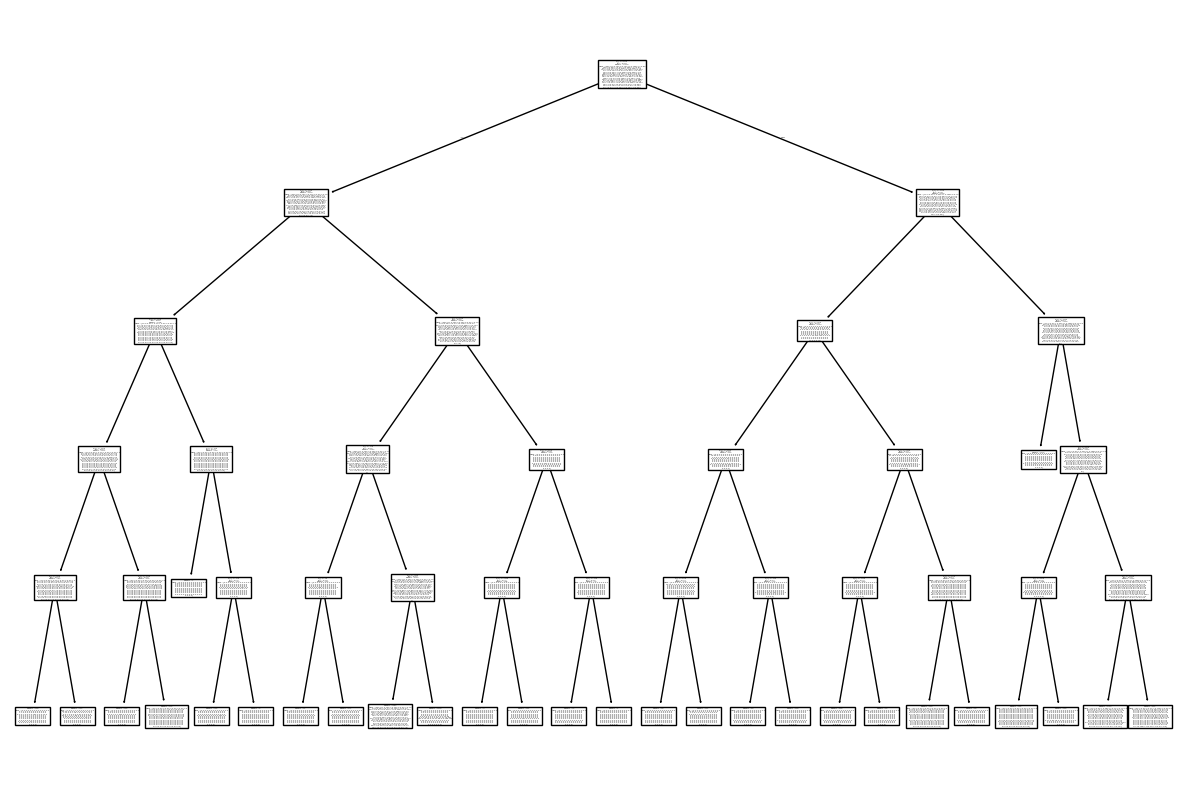

In [40]:
plt.figure(figsize=(15,10))
plot_tree(modelo3)
plt.show()

In [41]:
test_ejemplo3 = Explicativas3.sample()
test_ejemplo3

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 21 Secundario (cod+des),Proced 22 Secundario (cod+des),Proced 23 Secundario (cod+des),Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des)
13618,967,1609,1366,1163,1004,854,706,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [42]:
modelo3.predict_proba(test_ejemplo3)

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

In [43]:
predecir_grd3 = modelo3.predict(Explicativas3)
predecir_grd3

array([ 22,  26,  22, ..., 152,  22, 152], shape=(14278,))

In [44]:
dataset_el_pino['GRD'] == predecir_grd3

0        False
1        False
2        False
3        False
4        False
         ...  
14273    False
14274    False
14275    False
14276    False
14277    False
Name: GRD, Length: 14278, dtype: bool

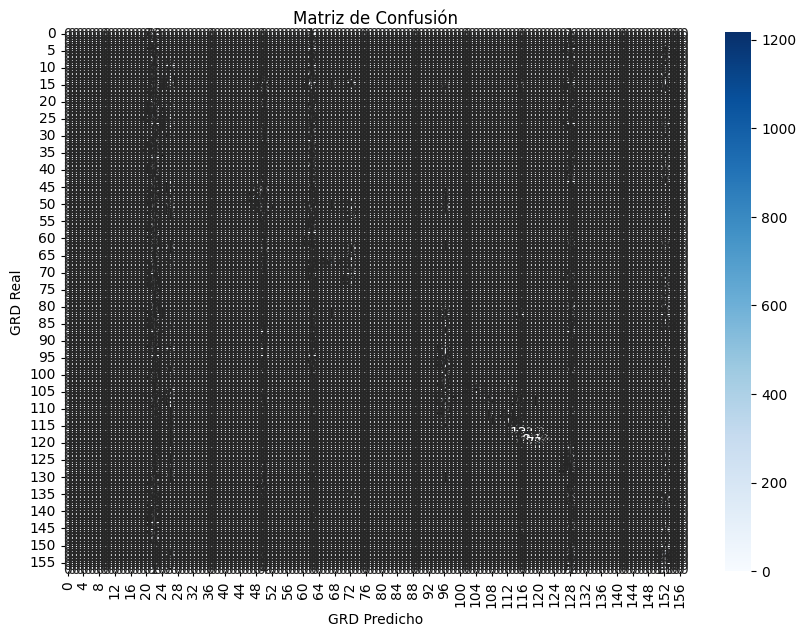

In [45]:
# Calcular la matriz de confusión
matriz_confusion3 = confusion_matrix(dataset_el_pino['GRD'], predecir_grd3)

# Mostrarla como heatmap
plt.figure(figsize=(10,7))
sns.heatmap(matriz_confusion3, annot=True, fmt="d", cmap="Blues")
plt.xlabel('GRD Predicho')
plt.ylabel('GRD Real')
plt.title('Matriz de Confusión')
plt.show()

In [46]:
porcentaje3 = np.round(((dataset_el_pino['GRD'] == predecir_grd3).sum())/rows * 100, decimals=2)
print(f"Porcentaje del modelo: {porcentaje3}%")

Porcentaje del modelo: 43.56%


In [47]:
medir_modelos(predecir_grd3)

Accuracy: 43.56%
Precision (macro): 7.50%
Recall (macro): 9.06%


/home/dalark/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Modelo 4

In [48]:
Explicativas4 = dataset_el_pino.drop(columns=delete_rows[1])
Objetivo4 = dataset_el_pino.GRD

In [49]:
modelo4 = DecisionTreeClassifier(max_depth=20)
modelo4.fit(Explicativas4, Objetivo4)

DecisionTreeClassifier(max_depth=20)

In [50]:
DecisionTreeClassifier()

DecisionTreeClassifier()

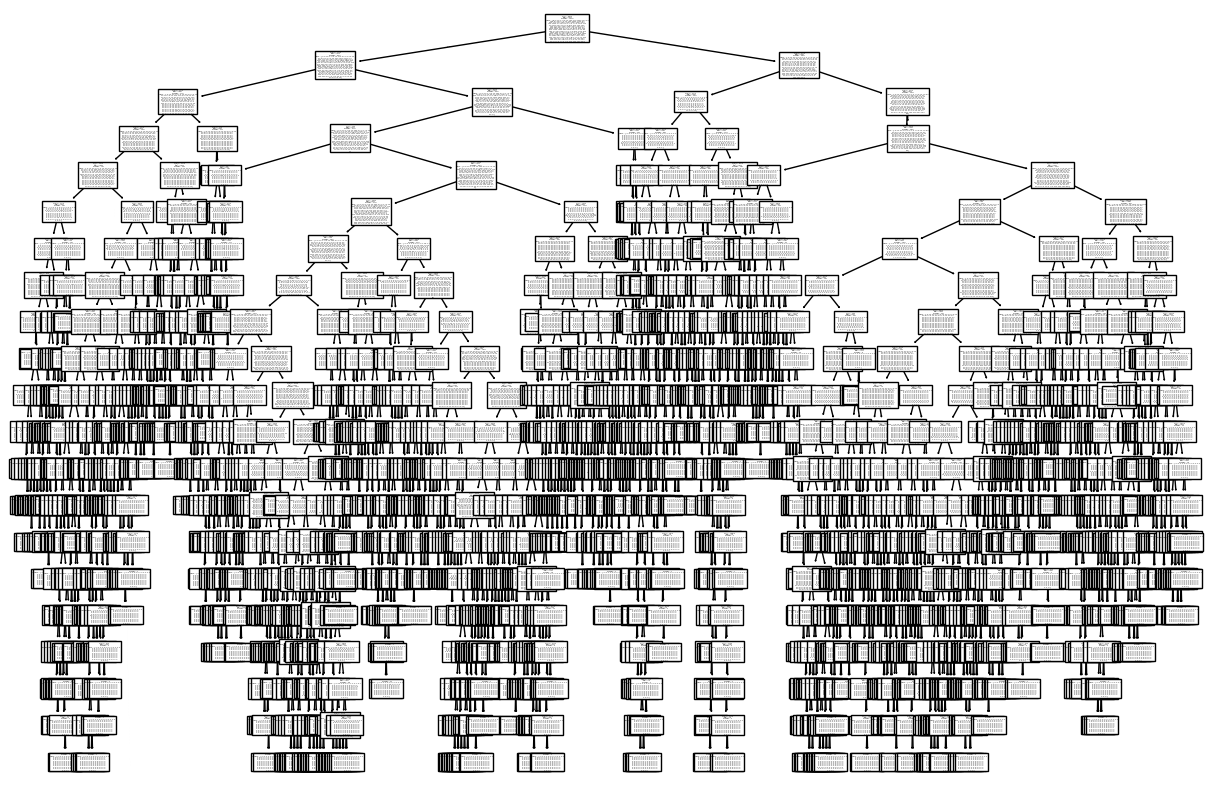

In [51]:
plt.figure(figsize=(15,10))
plot_tree(modelo4)
plt.show()

In [52]:
test_ejemplo4 = Explicativas4.sample()
test_ejemplo4

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 21 Secundario (cod+des),Proced 22 Secundario (cod+des),Proced 23 Secundario (cod+des),Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des)
13893,261,279,349,135,594,941,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [53]:
modelo4.predict_proba(test_ejemplo4)

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [54]:
predecir_grd4 = modelo4.predict(Explicativas4)
predecir_grd4

array([135,  14,  52, ...,   6,  62,  16], shape=(14278,))

In [55]:
dataset_el_pino['GRD'] == predecir_grd4

0         True
1         True
2        False
3         True
4         True
         ...  
14273     True
14274     True
14275     True
14276     True
14277     True
Name: GRD, Length: 14278, dtype: bool

In [56]:
porcentaje4 = np.round(((dataset_el_pino['GRD'] == predecir_grd4).sum())/rows * 100, decimals=2)
print(f"Porcentaje del modelo: {porcentaje4}%")

Porcentaje del modelo: 99.08%


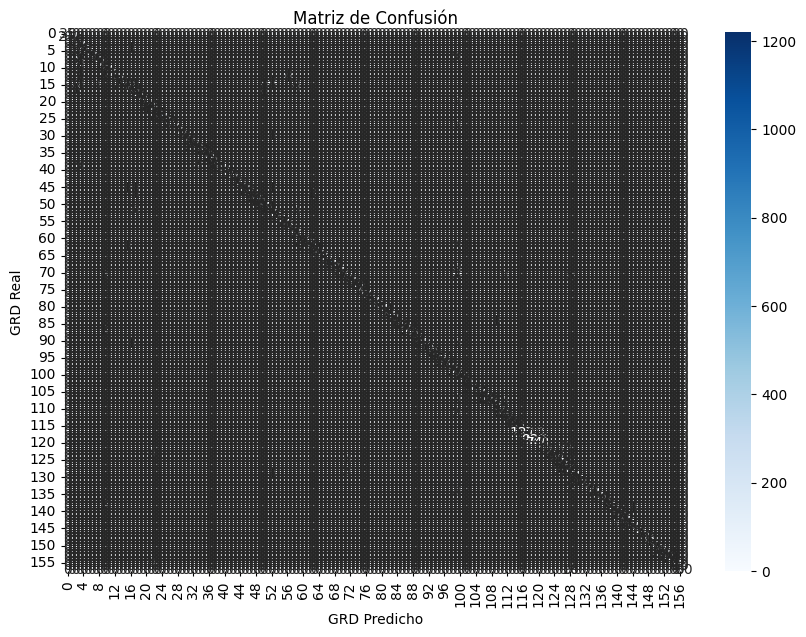

In [57]:
# Calcular la matriz de confusión
matriz_confusion4 = confusion_matrix(dataset_el_pino['GRD'], predecir_grd4)

# Mostrarla como heatmap
plt.figure(figsize=(10,7))
sns.heatmap(matriz_confusion4, annot=True, fmt="d", cmap="Blues")
plt.xlabel('GRD Predicho')
plt.ylabel('GRD Real')
plt.title('Matriz de Confusión')
plt.show()

In [58]:
medir_modelos(predecir_grd4)

Accuracy: 99.08%
Precision (macro): 97.66%
Recall (macro): 96.38%


## Modelo 5

In [59]:
Explicativas5 = dataset_el_pino.drop(columns=delete_rows[2])
Objetivo5 = dataset_el_pino.GRD

In [60]:
modelo5 = DecisionTreeClassifier(max_depth=5)
modelo5.fit(Explicativas5, Objetivo5)

DecisionTreeClassifier(max_depth=5)

In [61]:
DecisionTreeClassifier()

DecisionTreeClassifier()

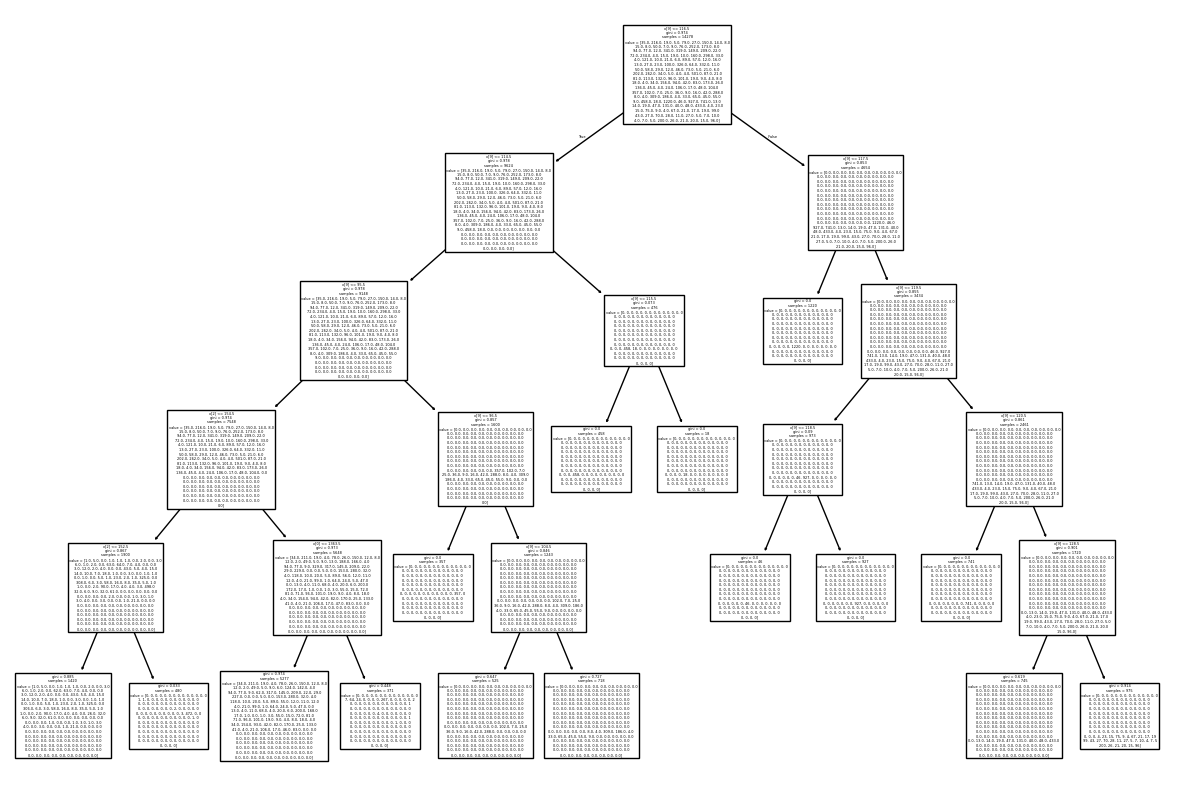

In [62]:
plt.figure(figsize=(15,10))
plot_tree(modelo5)
plt.show()

In [63]:
test_ejemplo5 = Explicativas5.sample()
test_ejemplo5

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Proced 01 Principal (cod+des),Proced 02 Secundario (cod+des),Proced 03 Secundario (cod+des),Proced 04 Secundario (cod+des),Proced 05 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
533,625,168,153,332,268,187,220,49,0,67


In [64]:
modelo5.predict_proba(test_ejemplo5)

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.00208333,
        0.00208333, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.00416667, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.00625   , 0.98333333, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

In [65]:
predecir_grd5 = modelo5.predict(Explicativas5)
predecir_grd5

array([152,  48,  22, ...,  22,  22,  22], shape=(14278,))

In [66]:
dataset_el_pino['GRD'] == predecir_grd5

0        False
1        False
2        False
3        False
4        False
         ...  
14273    False
14274    False
14275    False
14276    False
14277    False
Name: GRD, Length: 14278, dtype: bool

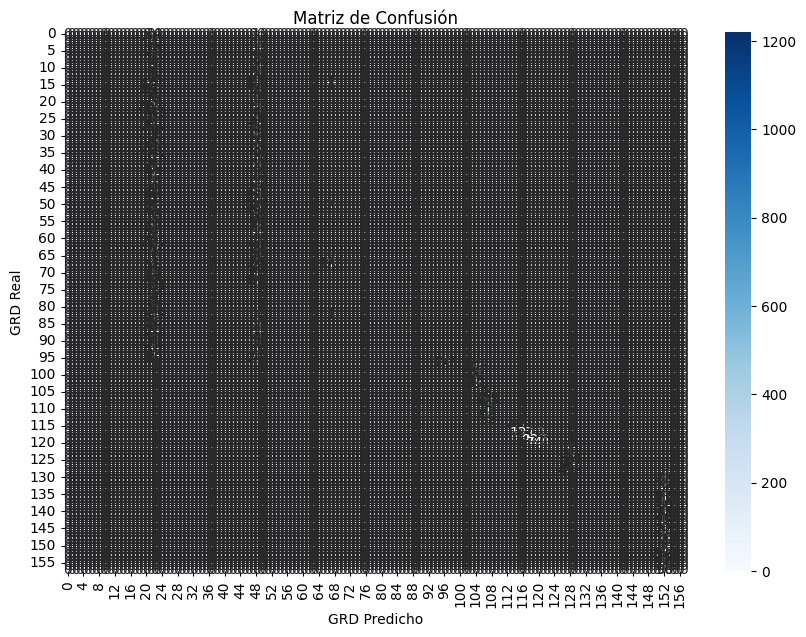

In [67]:
# Calcular la matriz de confusión
matriz_confusion5 = confusion_matrix(dataset_el_pino['GRD'], predecir_grd5)

# Mostrarla como heatmap
plt.figure(figsize=(10,7))
sns.heatmap(matriz_confusion5, annot=True, fmt="d", cmap="Blues")
plt.xlabel('GRD Predicho')
plt.ylabel('GRD Real')
plt.title('Matriz de Confusión')
plt.show()

In [68]:
porcentaje5 = np.round(((dataset_el_pino['GRD'] == predecir_grd5).sum())/rows * 100, decimals=2)
print(f"Porcentaje del modelo: {porcentaje5}%")

Porcentaje del modelo: 44.67%


In [69]:
medir_modelos(predecir_grd5)

Accuracy: 44.67%
Precision (macro): 6.81%
Recall (macro): 9.31%


/home/dalark/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Modelo 6

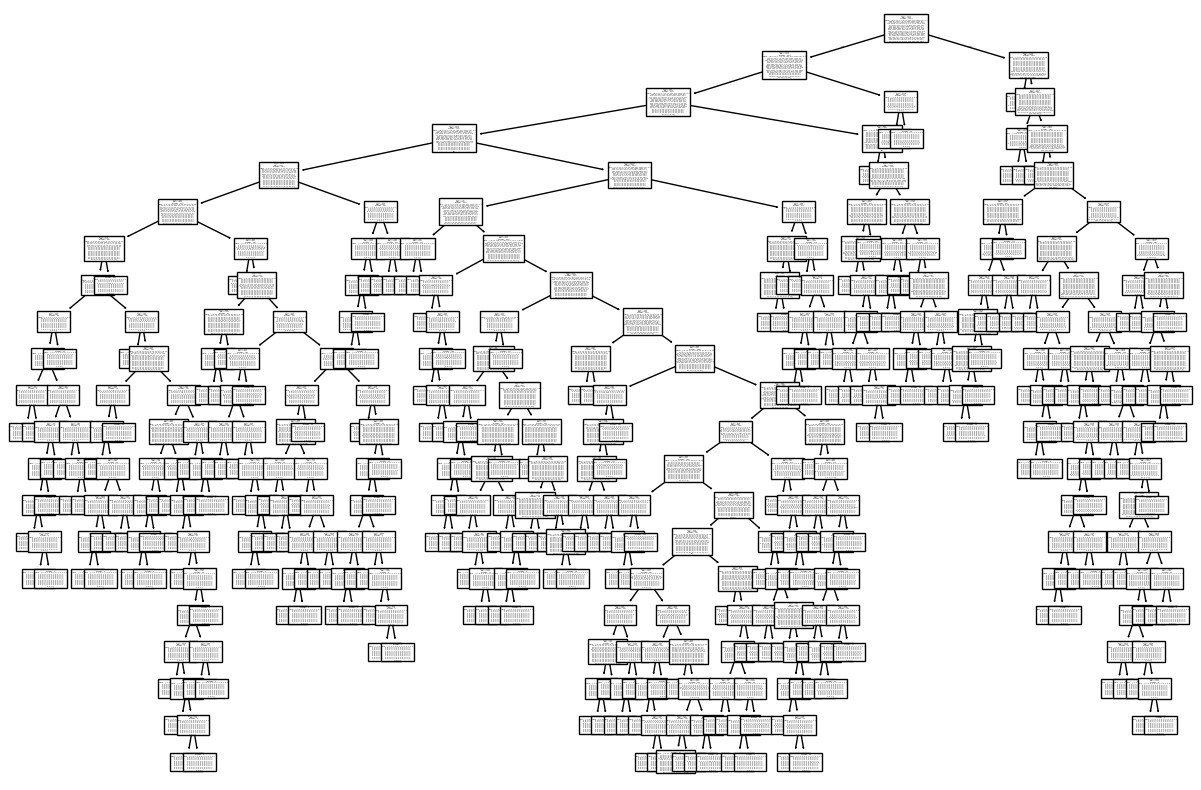

In [70]:
Explicativas6 = dataset_el_pino.drop(columns=delete_rows[2])
Objetivo6 = dataset_el_pino.GRD

modelo6 = DecisionTreeClassifier(max_depth=20)
modelo6.fit(Explicativas6, Objetivo6)

DecisionTreeClassifier()

plt.figure(figsize=(15,10))
plot_tree(modelo6)
plt.show()


In [71]:
test_ejemplo6 = Explicativas6.sample()
test_ejemplo6

modelo6.predict_proba(test_ejemplo6)

predecir_grd6 = modelo6.predict(Explicativas6)
predecir_grd6

dataset_el_pino['GRD'] == predecir_grd6


0        True
1        True
2        True
3        True
4        True
         ... 
14273    True
14274    True
14275    True
14276    True
14277    True
Name: GRD, Length: 14278, dtype: bool

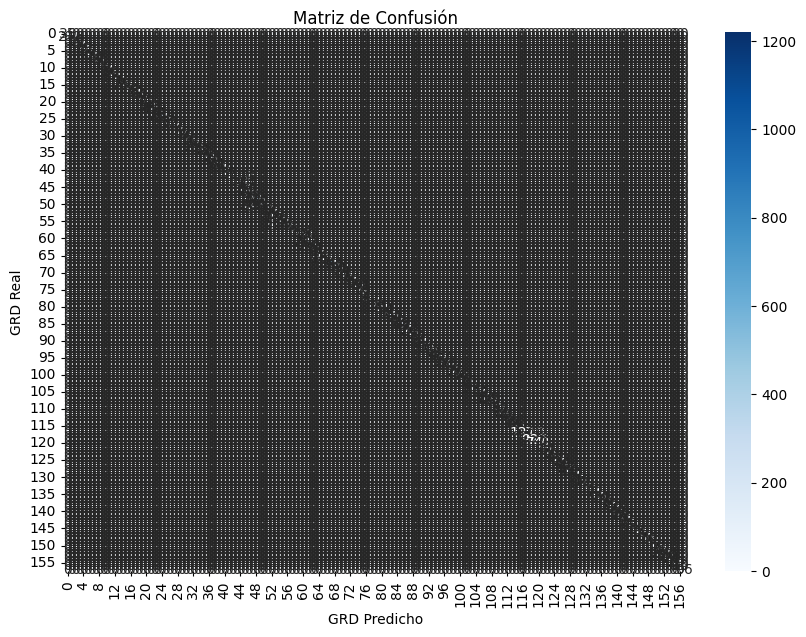

In [72]:
# Calcular la matriz de confusión
matriz_confusion6 = confusion_matrix(dataset_el_pino['GRD'], predecir_grd6)

# Mostrarla como heatmap
plt.figure(figsize=(10,7))
sns.heatmap(matriz_confusion6, annot=True, fmt="d", cmap="Blues")
plt.xlabel('GRD Predicho')
plt.ylabel('GRD Real')
plt.title('Matriz de Confusión')
plt.show()

In [73]:
porcentaje6 = np.round(((dataset_el_pino['GRD'] == predecir_grd6).sum())/rows * 100, decimals=2)
print(f"Porcentaje del modelo: {porcentaje6}%")

medir_modelos(predecir_grd6)

Porcentaje del modelo: 99.0%
Accuracy: 99.00%
Precision (macro): 95.54%
Recall (macro): 93.36%


/home/dalark/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Model 7

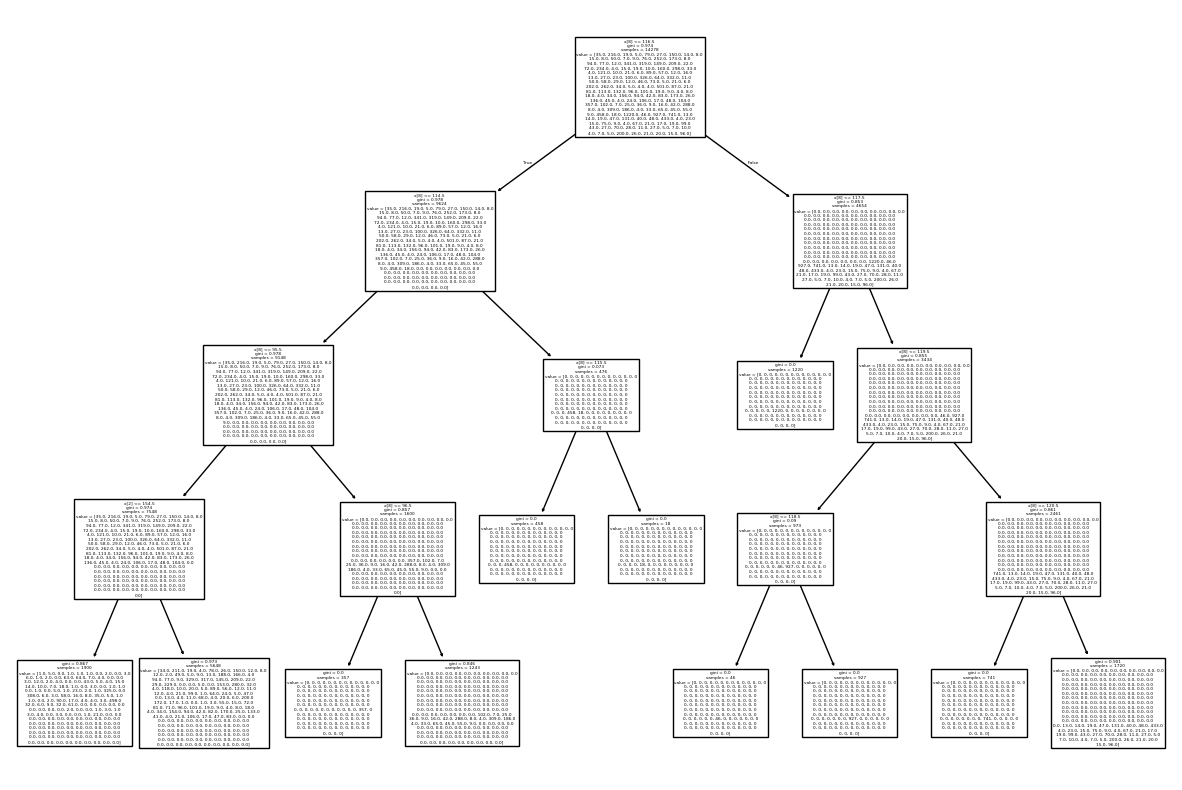

In [77]:
Explicativas7 = dataset_el_pino.drop(columns=delete_rows[3])
Objetivo7 = dataset_el_pino.GRD

modelo7 = DecisionTreeClassifier(max_depth=4)
modelo7.fit(Explicativas7, Objetivo7)

DecisionTreeClassifier()

plt.figure(figsize=(15,10))
plot_tree(modelo7)
plt.show()


In [78]:
test_ejemplo7 = Explicativas7.sample()
test_ejemplo7

modelo7.predict_proba(test_ejemplo7)

predecir_grd7 = modelo7.predict(Explicativas7)
predecir_grd7

dataset_el_pino['GRD'] == predecir_grd7

0        False
1        False
2        False
3        False
4        False
         ...  
14273    False
14274    False
14275    False
14276    False
14277    False
Name: GRD, Length: 14278, dtype: bool

In [ ]:
# Calcular la matriz de confusión
matriz_confusion7 = confusion_matrix(dataset_el_pino['GRD'], predecir_grd7)

# Mostrarla como heatmap
plt.figure(figsize=(10,7))
sns.heatmap(matriz_confusion7, annot=True, fmt="d", cmap="Blues")
plt.xlabel('GRD Predicho')
plt.ylabel('GRD Real')
plt.title('Matriz de Confusión')
plt.show()

In [79]:
porcentaje7 = np.round(((dataset_el_pino['GRD'] == predecir_grd7).sum())/rows * 100, decimals=2)
print(f"Porcentaje del modelo: {porcentaje7}%")

medir_modelos(predecir_grd7)

Porcentaje del modelo: 37.37%
Accuracy: 37.37%
Precision (macro): 4.95%
Recall (macro): 6.94%


/home/dalark/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Modelo 8 

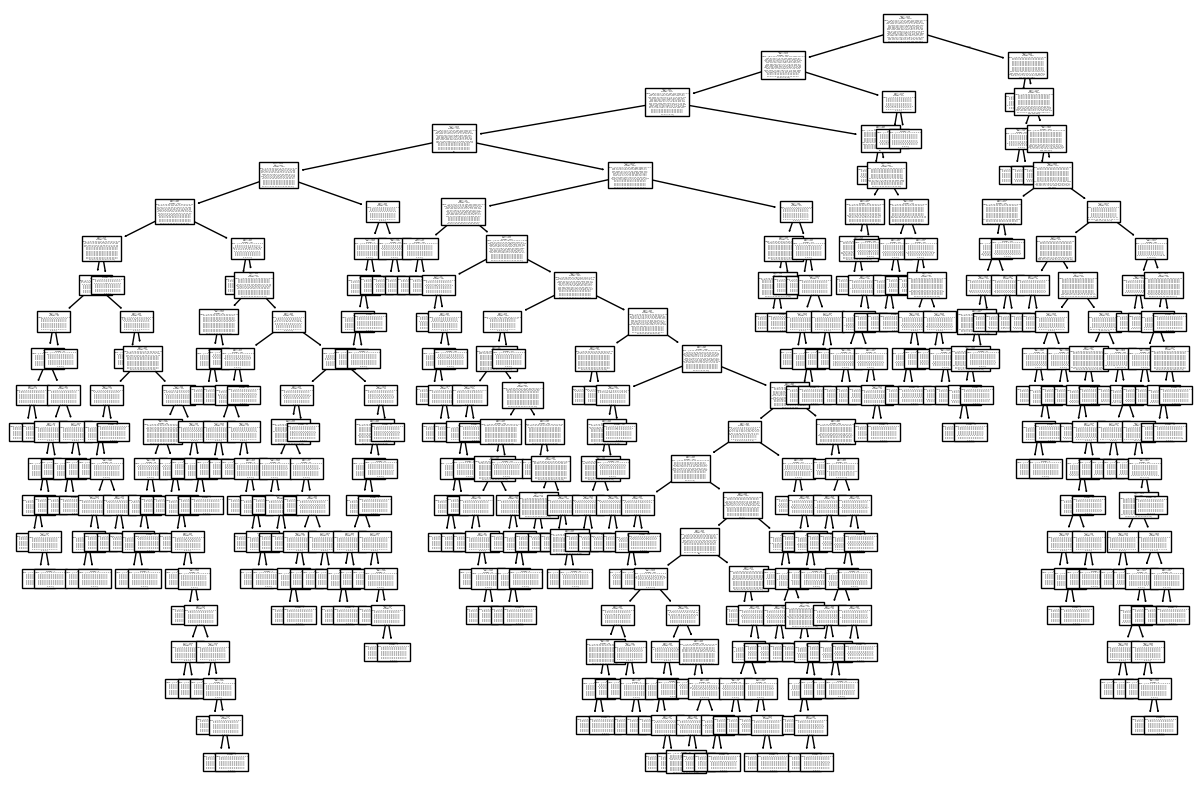

In [81]:
Explicativas8 = dataset_el_pino.drop(columns=delete_rows[3])
Objetivo8 = dataset_el_pino.GRD

modelo8 = DecisionTreeClassifier(max_depth=20)
modelo8.fit(Explicativas8, Objetivo8)

DecisionTreeClassifier()

plt.figure(figsize=(15,10))
plot_tree(modelo8)
plt.show()

In [83]:
test_ejemplo8 = Explicativas8.sample()
test_ejemplo8

modelo8.predict_proba(test_ejemplo8)

predecir_grd8 = modelo8.predict(Explicativas8)
predecir_grd8

dataset_el_pino['GRD'] == predecir_grd8

0        True
1        True
2        True
3        True
4        True
         ... 
14273    True
14274    True
14275    True
14276    True
14277    True
Name: GRD, Length: 14278, dtype: bool

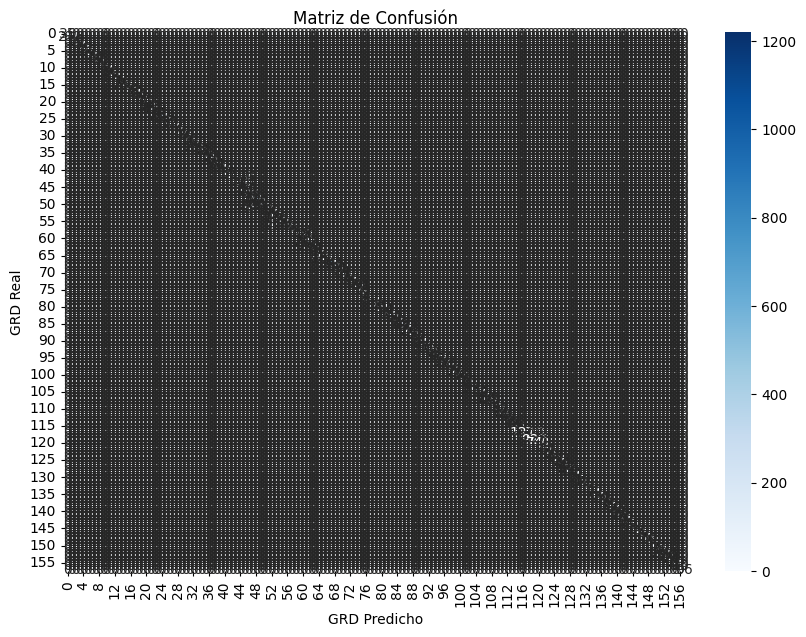

In [84]:
# Calcular la matriz de confusión
matriz_confusion8 = confusion_matrix(dataset_el_pino['GRD'], predecir_grd8)

# Mostrarla como heatmap
plt.figure(figsize=(10,7))
sns.heatmap(matriz_confusion8, annot=True, fmt="d", cmap="Blues")
plt.xlabel('GRD Predicho')
plt.ylabel('GRD Real')
plt.title('Matriz de Confusión')
plt.show()

In [85]:
porcentaje8 = np.round(((dataset_el_pino['GRD'] == predecir_grd8).sum())/rows * 100, decimals=2)
print(f"Porcentaje del modelo: {porcentaje8}%")

medir_modelos(predecir_grd8)

Porcentaje del modelo: 99.0%
Accuracy: 99.00%
Precision (macro): 95.54%
Recall (macro): 93.36%


/home/dalark/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
